# 02 · Monte Carlo versus temporal difference

[Course README](../README.md) · README topics **17–18**

**Goal.** Estimate the same policy value from complete returns and one-step bootstrap targets, then compare learning error across random seeds.

**How to run:** select **Restart Kernel and Run All**. Every required function is defined
in this notebook; run cells in order. The defaults are small CPU experiments, not benchmark
training runs. Install the root `requirements.txt` once before opening Jupyter.
No cells install packages, download data, or require account credentials.

<img src="../assets/diagrams/td-learning.svg" width="760" alt="Overview of Monte Carlo versus temporal difference">

## 1. A random walk with a known answer

Five nonterminal states sit between a left and a right exit. Start in the middle (state 3).
The fixed policy moves left or right with equal probability. The reward is **+1 only on
entering the right exit** and zero otherwise. Both exits terminate the episode; γ = 1.

The value at interior state i is the probability of reaching the right exit first, `i / 6`.
Although entering the right exit pays 1, its **terminal value is zero**: that reward has already
arrived. The analytic solution will help separate estimator error from plot interpretation.

**Analogy:** MC rates the whole completed journey. TD updates at the next checkpoint using
its current estimate of the remaining journey. Neither method is told which individual move is correct.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({
    'figure.figsize': (9, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]),
    'axes.grid': True, 'grid.alpha': 0.18,
})
np.set_printoptions(precision=3, suppress=True)
print(f'Python {platform.python_version()} | NumPy {np.__version__}')

Python 3.12.4 | NumPy 1.26.4


In [2]:
N = 5
TRUE_VALUES = np.arange(1, N + 1) / (N + 1)

def sample_episode(rng):
    """Generate (state, reward, next_state, terminated) under the fixed random policy."""
    state, transitions = 3, []
    while True:
        next_state = state + rng.choice([-1, 1])
        terminated = next_state in (0, N + 1)
        transitions.append((state, float(next_state == N + 1), next_state, terminated))
        if terminated:
            return transitions
        state = next_state

episode = sample_episode(np.random.default_rng(7))
print('Example trajectory:', [episode[0][0]] + [t[2] for t in episode])
print('Observed rewards:', [t[1] for t in episode])
print('True interior values:', TRUE_VALUES)

Example trajectory: [3, 4, 5, 6]
Observed rewards: [0.0, 0.0, 1.0]
True interior values: [0.167 0.333 0.5   0.667 0.833]


## 2. Implement first-visit MC and TD(0)

Both updates have the form `estimate += alpha * (target - estimate)`.

| Estimator | Target | When the target is available |
| --- | --- | --- |
| First-visit Monte Carlo | Full observed return G | At episode completion |
| TD(0) | reward + next-state value | After one transition |

First-visit MC updates each state at its first occurrence in an episode. A state may appear
many times; we calculate all returns backward, then select first occurrences going forward.
TD uses every observed transition. The learning rates are illustrative, not tuned to make one
algorithm win. Constant rates mean estimates keep responding to recent experience.

In [3]:
def mc_update(values, episode, alpha):
    """First-visit MC prediction for gamma=1; modify the value table in place."""
    returns = np.zeros(len(episode))
    total = 0.0
    for t in reversed(range(len(episode))):
        total = episode[t][1] + total
        returns[t] = total
    visited = set()
    for t, (state, _, _, _) in enumerate(episode):
        if state not in visited:
            values[state] += alpha * (returns[t] - values[state])
            visited.add(state)

def td_update(values, episode, alpha):
    """Online-order TD(0) prediction for gamma=1 with no terminal bootstrap."""
    for state, reward, next_state, terminated in episode:
        target = reward + (0.0 if terminated else values[next_state])
        values[state] += alpha * (target - values[state])

# A terminal next-state estimate must never leak into the target.
probe = np.zeros(N + 2); probe[-1] = 123.0
td_update(probe, [(5, 1.0, 6, True)], alpha=1.0)
assert probe[5] == 1.0
# State 3 is visited twice, but first-visit MC updates it only once.
probe = np.zeros(N + 2)
mc_update(probe, [(3, 0, 4, False), (4, 0, 3, False), (3, 1, 6, True)], alpha=0.5)
assert probe[3] == 0.5
print('Terminal masking and first-visit checks passed.')

Terminal masking and first-visit checks passed.


## 3. A paired experiment across 12 seeds

For each seed, both learners receive the **same episodes**. This controls one source of
experimental noise. We measure root mean squared error against all five true values after
each episode. Bands below show **one standard error across independent training seeds**;
they are not confidence intervals for a universally best algorithm.

In [4]:
SEEDS = range(12)
EPISODES = 300
ALPHA_MC, ALPHA_TD = 0.03, 0.10
errors = np.zeros((len(SEEDS), 2, EPISODES))
final_values = np.zeros((len(SEEDS), 2, N))
for run, seed in enumerate(SEEDS):
    rng = np.random.default_rng(seed)
    mc = np.r_[0.0, np.full(N, 0.5), 0.0]
    td = mc.copy()
    for ep in range(EPISODES):
        trajectory = sample_episode(rng)
        mc_update(mc, trajectory, ALPHA_MC)
        td_update(td, trajectory, ALPHA_TD)
        for method, values in enumerate([mc, td]):
            errors[run, method, ep] = np.sqrt(np.mean((values[1:-1] - TRUE_VALUES) ** 2))
    final_values[run] = [mc[1:-1], td[1:-1]]
assert np.isfinite(errors).all()
for method, name in enumerate(['First-visit MC', 'TD(0)']):
    print(f'{name}: final RMSE {errors[:, method, -1].mean():.3f}')

First-visit MC: final RMSE 0.051
TD(0): final RMSE 0.055


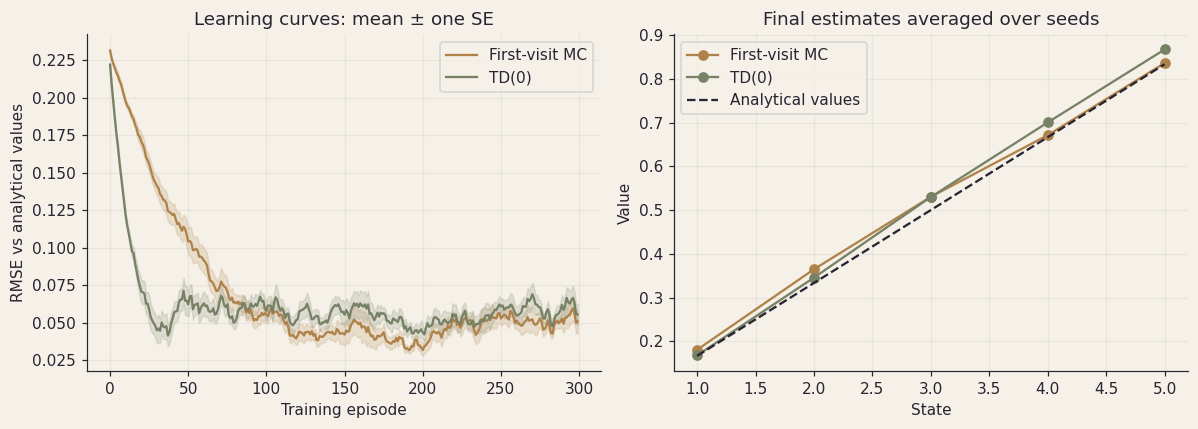

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for method, name in enumerate(['First-visit MC', 'TD(0)']):
    mean = errors[:, method].mean(axis=0)
    se = errors[:, method].std(axis=0, ddof=1) / np.sqrt(len(SEEDS))
    line, = axes[0].plot(mean, label=name)
    axes[0].fill_between(np.arange(EPISODES), mean-se, mean+se, color=line.get_color(), alpha=0.18)
    axes[1].plot(range(1, N+1), final_values[:, method].mean(axis=0), marker='o', label=name)
axes[0].set(xlabel='Training episode', ylabel='RMSE vs analytical values', title='Learning curves: mean ± one SE')
axes[1].plot(range(1, N+1), TRUE_VALUES, '--', color=INK, label='Analytical values')
axes[1].set(xlabel='State', ylabel='Value', title='Final estimates averaged over seeds')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## 4. Target variance and bootstrap bias

At the middle state, the full MC return is either 0 or 1. If TD could use the **true** values,
its target would be 2/6 or 4/6. Both targets have mean 1/2, but the one-step target has lower
variance here. With an inaccurate bootstrap table, its target can also be biased.

This oracle calculation explains a mechanism; it does not mean TD has access to the true
values during training. MC's sampled target avoids bootstrap bias, while learned estimates
can still have finite-sample and initialization error.

In [6]:
mc_targets = np.array([0.0, 1.0])
oracle_td_targets = np.array([2/6, 4/6])
bad_td_targets = np.array([0.9, 0.9])
for name, targets in [('MC', mc_targets), ('TD with exact V', oracle_td_targets), ('TD with wrong V', bad_td_targets)]:
    print(f'{name:18s}: mean={targets.mean():.3f}, variance={targets.var():.4f}, bias={targets.mean()-0.5:+.3f}')
assert np.isclose(mc_targets.mean(), oracle_td_targets.mean())
assert oracle_td_targets.var() < mc_targets.var()

MC                : mean=0.500, variance=0.2500, bias=+0.000
TD with exact V   : mean=0.500, variance=0.0278, bias=+0.000
TD with wrong V   : mean=0.900, variance=0.0000, bias=+0.400


## Exercises

1. Use the same alpha for both methods. Does the ranking change?
2. Initialize all nonterminal values to zero. Which method propagates reward sooner?
3. Implement every-visit MC and compare it with first-visit MC.
4. Increase the walk length and explain how the targets change.

<details>
<summary>Hints and expected reasoning — open after trying the exercises</summary>

1. Step sizes strongly affect speed and final noise.
2. TD propagates local estimates over experience; MC carries a completed outcome directly to earlier visits.
3. Remove the visited set, but remember visits from the same episode are correlated.
4. Generalize the start state and analytical i/(N+1) formula; longer walks usually need more data.

</details>

## What to remember

Compare estimators on common data and known answers. Bootstrapping trades dependence on learned predictions for the ability to update from partial experience.

## Further reading

- Sutton and Barto, [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html). Chapters 5–6.

[← Previous notebook](01_mdp_dynamic_programming.ipynb) · [Next notebook →](03_q_learning.ipynb)